Dimensiones originales: (15568, 50)
Dimensiones solo Medellín: (2487, 50)
Dimensiones después limpieza: (1913, 14)

RESULTADOS RANDOM FOREST
MAE: 467640.96
RMSE: 719536.02
R²: 0.9611
MAPE: 5.68 %

Cross Validation R²:
[0.9606751  0.95710856 0.96265485 0.95033256 0.95801334]
Promedio: 0.9578

TOP VARIABLES IMPORTANTES
                                       Variable  Importancia
83                                 num__Estrato     0.590711
42                               cat__Tipo_Lote     0.085396
84                    num__Área promedio oferta     0.069493
0                           cat__Zona_Campestre     0.046833
87             num__Total unidades del proyecto     0.033689
17                     cat__Sub Zona_El Poblado     0.027370
88                    num__Unidades disponibles     0.024985
90                    num__% Vendido total (un)     0.019020
86                num__Ventas Promedio Mes (un)     0.014369
63                      cat__Estado Obra_Prev./     0.011303
26        

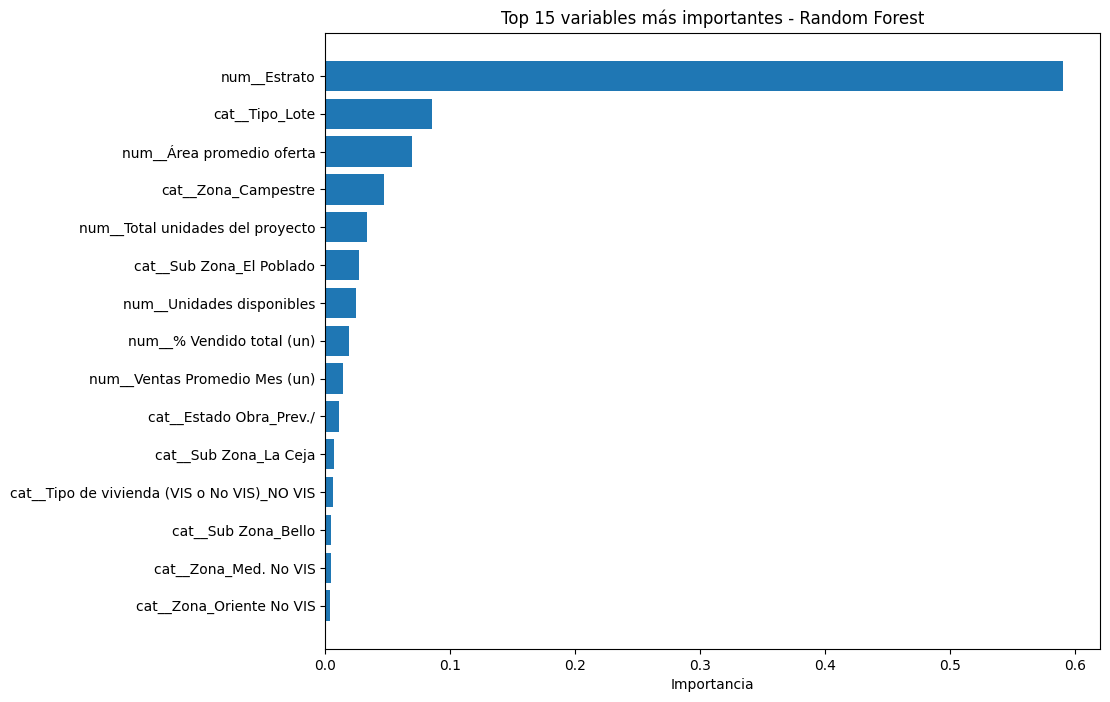


PREDICCIÓN RANDOM FOREST
Precio estimado m²: 12479107.0


In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


# ============================================================
# 2. CARGAR EXCEL
# ============================================================

ruta = r"C:\Users\Usuario\Desktop\Trabajo Final Aprendizaje Maquinas\Base competitividad-Completa.xlsx"

df = pd.read_excel(ruta)

print("Dimensiones originales:", df.shape)


# ============================================================
# 3. FILTRAR SOLO MEDELLÍN
# ============================================================

df['Ciudad'] = df['Ciudad'].astype(str).str.strip()

df = df[df['Ciudad'].str.upper() == 'MEDELLIN']

print("Dimensiones solo Medellín:", df.shape)


# ============================================================
# 4. SELECCIÓN DE VARIABLES
# ============================================================

columnas_modelo = [
    'Zona',
    'Sub Zona',
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra',
    '$ Prom. Oferta m2'
]

df = df[columnas_modelo].copy()


# ============================================================
# 5. LIMPIEZA TARGET
# ============================================================

df['$ Prom. Oferta m2'] = pd.to_numeric(
    df['$ Prom. Oferta m2'],
    errors='coerce'
)

df = df[df['$ Prom. Oferta m2'].notnull()]

df = df[df['$ Prom. Oferta m2'] > 1000000]
df = df[df['$ Prom. Oferta m2'] < 50000000]


# ============================================================
# 6. VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ============================================================

numericas = [
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)'
]

categoricas = [
    'Zona',
    'Sub Zona',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra'
]

for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in categoricas:
    df[col] = df[col].fillna('Desconocido')
    df[col] = df[col].astype(str)


# ============================================================
# 7. ELIMINAR OUTLIERS
# ============================================================

Q1 = df['$ Prom. Oferta m2'].quantile(0.25)
Q3 = df['$ Prom. Oferta m2'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df = df[
    (df['$ Prom. Oferta m2'] >= lim_inf) &
    (df['$ Prom. Oferta m2'] <= lim_sup)
]

print("Dimensiones después limpieza:", df.shape)


# ============================================================
# 8. DEFINIR X E Y
# ============================================================

X = df.drop(columns=['$ Prom. Oferta m2'])
y = df['$ Prom. Oferta m2']


# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 10. PREPROCESAMIENTO
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ('num', 'passthrough', numericas)
    ]
)


# ============================================================
# 11. MODELO RANDOM FOREST
# ============================================================

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', rf)
    ]
)


# ============================================================
# 12. ENTRENAR
# ============================================================

modelo_rf.fit(X_train, y_train)


# ============================================================
# 13. PREDICCIÓN TEST
# ============================================================

y_pred = modelo_rf.predict(X_test)


# ============================================================
# 14. MÉTRICAS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nRESULTADOS RANDOM FOREST")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))
print("MAPE:", round(mape, 2), "%")


# ============================================================
# 15. CROSS VALIDATION
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("\nCross Validation R²:")
print(cv_scores)
print("Promedio:", round(cv_scores.mean(), 4))


# ============================================================
# 16. IMPORTANCIA VARIABLES
# ============================================================

modelo_rf.fit(X, y)

feature_names = modelo_rf.named_steps['preprocessor'].get_feature_names_out()
importancias = modelo_rf.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importancias
})

imp_df = imp_df.sort_values(
    by='Importancia',
    ascending=False
)

print("\nTOP VARIABLES IMPORTANTES")
print(imp_df.head(15))


# ============================================================
# 17. GRÁFICA
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    imp_df.head(15)['Variable'],
    imp_df.head(15)['Importancia']
)

plt.gca().invert_yaxis()

plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')

plt.show()


# ============================================================
# 18. PREDICCIÓN NUEVO CASO
# ============================================================

nuevo = pd.DataFrame({
    'Zona': ['El Poblado'],
    'Sub Zona': ['Castropol'],
    'Estrato': [6],
    'Área promedio oferta': [95],
    'Meses activo': [2],
    'Ventas Promedio Mes (un)': [4],
    'Total unidades del proyecto': [180],
    'Unidades disponibles': [150],
    'Unidades por lanzar': [60],
    '% Vendido total (un)': [12],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Preventa']
})

pred = modelo_rf.predict(nuevo)

print("\nPREDICCIÓN RANDOM FOREST")
print("Precio estimado m²:", round(pred[0], 0))

In [2]:
nuevo = pd.DataFrame({
       # OJO: si tu base maneja SABANETA como ciudad, cambia a 'Sabaneta'
    'Zona': ['Sabaneta'],
    'Sub Zona': ['Aves Maria'],
    'Estrato': [4],
    'Área promedio oferta': [78],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [9],
    'Total unidades del proyecto': [140],
    'Unidades disponibles': [28],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [80],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo_rf.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 8829078.0


In [4]:
nuevo = pd.DataFrame({
    'Zona': ['El Poblado'],
    'Sub Zona': ['Milla de Oro'],
    'Estrato': [6],
    'Área promedio oferta': [110],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [10],
    'Total unidades del proyecto': [90],
    'Unidades disponibles': [12],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [87],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo_rf.predict(nuevo)


print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 11784361.0
